# Project 1 — Анализ застройки и землепользования

**Курс:** Пространственный анализ на Python (HSE, 2026)
**Район:** Хамовники, Москва

## Цель
Разбираю структуру землепользования Хамовников и считаю, какая доля территории
района занята застройкой — по данным OpenStreetMap.

## Ход работы
1. Загружаю здания и зоны землепользования из OSM
2. Смотрю, что пришло в данных
3. Чищу: оставляю только полигоны и нужные поля
4. Перевожу в метрическую проекцию (UTM)
5. Считаю долю застроенной территории
6. Разбиваю землепользование по типам и считаю доли
7. Рисую карты и круговую диаграмму
8. Сохраняю обработанные слои
9. Делаю выводы

## 0. Библиотеки

Подключаю всё, что использую дальше.

In [1]:
pip install osmnx geopandas matplotlib mapclassify shapely

  Using cached mapclassify-2.8.1-py3-none-any.whl (59 kB)



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("osmnx   :", ox.__version__)
print("geopandas:", gpd.__version__)

# Единые настройки графиков
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10


osmnx   : 2.0.7
geopandas: 1.0.1


### Параметры

Задаю район и теги OSM, которые буду загружать.

In [3]:
PLACE = "Khamovniki District, Moscow, Russia"

# Теги OSM для загрузки
TAGS_BUILDINGS = {"building": True}     # все здания
TAGS_LANDUSE   = {"landuse": True}      # все зоны землепользования


## 1. Загрузка данных из OpenStreetMap

Беру три слоя: границу района, здания и зоны землепользования.

In [4]:
# Граница района (полигон)
boundary = ox.geocode_to_gdf(PLACE)
print("Граница загружена:", boundary.shape)
boundary[["display_name", "geometry"]].head()


Граница загружена: (1, 17)


,display_name,geometry
0,"Khamovniki District, Moscow, Central Federal D...","POLYGON ((37.54108 55.72013, 37.54189 55.71759..."


In [5]:
# Здания
buildings_raw = ox.features_from_place(PLACE, tags=TAGS_BUILDINGS)
print("Здания (сырые):", buildings_raw.shape)

# Землепользование
landuse_raw = ox.features_from_place(PLACE, tags=TAGS_LANDUSE)
print("Землепользование (сырое):", landuse_raw.shape)


Здания (сырые): (2837, 228)
Землепользование (сырое): (723, 71)


## 2. Разведочный анализ

Смотрю на размер слоёв, типы геометрии и основные атрибуты — чтобы понять, с чем работаю.

In [6]:
print("=== ЗДАНИЯ ===")
print("Объектов:", len(buildings_raw))
print("Колонок :", buildings_raw.shape[1])
print("Типы геометрии:")
print(buildings_raw.geom_type.value_counts())
print("\nЧастые значения тега building:")
print(buildings_raw["building"].value_counts().head(10))


=== ЗДАНИЯ ===
Объектов: 2837
Колонок : 228
Типы геометрии:
Polygon         2805
Point             22
MultiPolygon      10
Name: count, dtype: int64

Частые значения тега building:
building
yes             1067
apartments       614
office           301
service          212
commercial       118
retail            41
hospital          41
government        34
construction      33
garages           30
Name: count, dtype: int64


In [7]:
print("=== ЗЕМЛЕПОЛЬЗОВАНИЕ ===")
print("Объектов:", len(landuse_raw))
print("Типы геометрии:")
print(landuse_raw.geom_type.value_counts())
print("\nКатегории landuse:")
print(landuse_raw["landuse"].value_counts())


=== ЗЕМЛЕПОЛЬЗОВАНИЕ ===
Объектов: 723
Типы геометрии:
Polygon         707
MultiPolygon     16
Name: count, dtype: int64

Категории landuse:
landuse
grass               503
residential         103
commercial           38
construction         22
flowerbed            18
religious            14
railway               6
industrial            4
military              4
brownfield            3
institutional         2
forest                2
retail                2
cemetery              1
embassy_compound      1
Name: count, dtype: int64


## 3. Обработка данных

Площадь корректно считается только по полигонам, поэтому оставляю `Polygon` и
`MultiPolygon`, а точки и линии убираю. Заодно оставляю только нужные поля.

In [8]:
def keep_polygons(gdf, cols):
    """Оставляет только полигональные объекты и заданные поля."""
    poly = gdf[gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    cols = [c for c in cols if c in poly.columns]
    return poly[cols + ["geometry"]]

buildings = keep_polygons(buildings_raw, ["building", "name"])
landuse   = keep_polygons(landuse_raw,   ["landuse", "name"])

print("Здания (полигоны):       ", len(buildings))
print("Землепользование (полигоны):", len(landuse))
buildings.head()


Здания (полигоны):        2815
Землепользование (полигоны): 723


building  \
element  id                   
relation 69968   university   
         361992      office   
         421694         yes   
         421703      public   
         421723  university   

                                                              name  \
element  id                                                          
relation 69968                                                 NaN   
         361992                          ФГУП МИА «Россия сегодня»   
         421694         Государственный архив Российской Федерации   
         421703                                                NaN   
         421723  Первый московский государственный медицинский ...   

                                                          geometry  
element  id                                                         
relation 69968   POLYGON ((37.58066 55.72139, 37.58063 55.7214,...  
         361992  POLYGON ((37.58924 55.738, 37.58926 55.73799, ...  
         421694  POLYGON ((37.57389 55.73285, 37.57386 55.73287...  
         421703  POLYGON ((37.55516 55.71923, 37.5557 55.71953,...  
         421723  POLYGON ((37.5748 55.72816, 37.57534 55.72778,...

## 4. Перепроецирование в метрическую систему (UTM)

Координаты в исходных данных в градусах (`EPSG:4326`), площади в них считать нельзя.
Перевожу всё в UTM-зону (для Москвы это 37N) — тогда площади получаются в м². И сразу
обрезаю слои по границе района, чтобы учитывать только то, что внутри.

In [9]:
# Определяем подходящую зону UTM по границе района
utm_crs = boundary.estimate_utm_crs()
print("Целевая система координат:", utm_crs)

boundary_m  = boundary.to_crs(utm_crs)
buildings_m = buildings.to_crs(utm_crs)
landuse_m   = landuse.to_crs(utm_crs)

# Обрезаем по границе района
buildings_m = gpd.clip(buildings_m, boundary_m)
landuse_m   = gpd.clip(landuse_m, boundary_m)

print("После обрезки — зданий:", len(buildings_m), "| зон landuse:", len(landuse_m))


Целевая система координат: EPSG:32637


После обрезки — зданий: 2815 | зон landuse: 723


## 5. Доля застроенной территории

Площадь района беру как площадь полигона границы, застройку — как площадь полигонов
зданий. Здания в OSM местами накладываются друг на друга, поэтому застройку считаю по
объединению геометрий (`union_all`): простая сумма площадей завышала бы результат.

In [10]:
district_area = boundary_m.area.sum()

# Простая сумма (может завышать из-за наложений)
building_area_sum = buildings_m.area.sum()

# Площадь объединения геометрий — без двойного учёта
building_footprint = buildings_m.union_all()
building_area_union = building_footprint.area

pct_sum   = building_area_sum   / district_area * 100
pct_union = building_area_union / district_area * 100

print(f"Площадь района:            {district_area/1e6:8.3f} км²")
print(f"Площадь застройки (сумма): {building_area_sum/1e6:8.3f} км²  -> {pct_sum:5.2f}%")
print(f"Площадь застройки (union): {building_area_union/1e6:8.3f} км²  -> {pct_union:5.2f}%")
print()
print(f">>> Доля застроенной территории: {pct_union:.2f}%")


Площадь района:              10.070 км²
Площадь застройки (сумма):    2.068 км²  -> 20.54%
Площадь застройки (union):    2.043 км²  -> 20.29%

>>> Доля застроенной территории: 20.29%


## 6. Землепользование по типам

Группирую зоны по типу и считаю площадь и долю каждого. Зоны landuse покрывают не весь
район и кое-где пересекаются, поэтому смотрю долю и внутри размеченной территории, и от
всей площади района.

In [11]:
lu = landuse_m.copy()
lu["area_m2"] = lu.area

by_type = (lu.groupby("landuse")["area_m2"].sum()
             .sort_values(ascending=False))

total_landuse_area = by_type.sum()

summary = pd.DataFrame({
    "area_km2": by_type / 1e6,
    "share_of_landuse_%": by_type / total_landuse_area * 100,
    "share_of_district_%": by_type / district_area * 100,
})
print(f"Размечено landuse: {total_landuse_area/district_area*100:.1f}% площади района\n")
summary.round(2)


Размечено landuse: 60.9% площади района



,area_km2,share_of_landuse_%,share_of_district_%
landuse,,,
residential,3.94,64.27,39.14
commercial,0.74,11.99,7.30
grass,0.58,9.45,5.75
construction,0.21,3.46,2.10
religious,0.18,2.86,1.74
military,0.17,2.69,1.64
institutional,0.16,2.63,1.60
brownfield,0.07,1.18,0.72
cemetery,0.06,0.94,0.57


## 7. Карты и диаграммы

### 7.1 Карта зданий

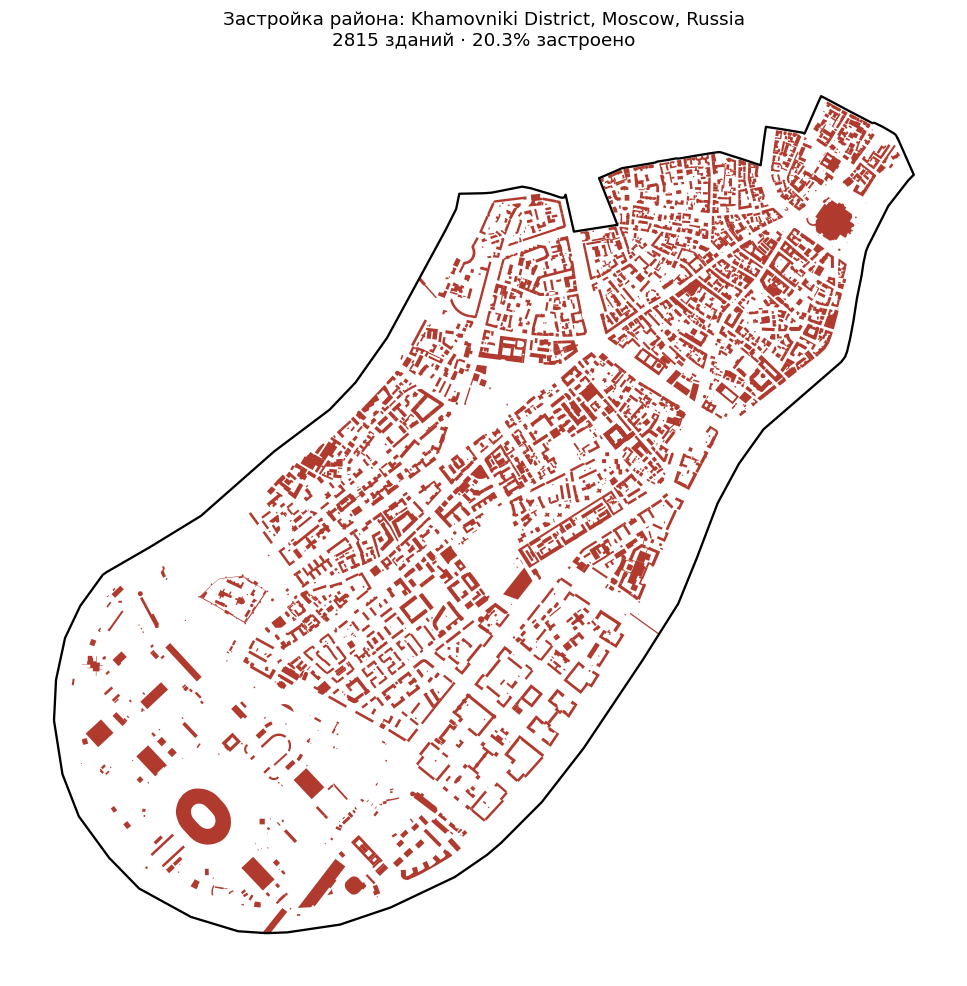

In [12]:
fig, ax = plt.subplots(figsize=(9, 9))
boundary_m.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, zorder=3)
buildings_m.plot(ax=ax, color="#b03a2e", edgecolor="none", zorder=2)

ax.set_title(f"Застройка района: {PLACE}\n"
             f"{len(buildings_m)} зданий · {pct_union:.1f}% застроено",
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


### 7.2 Карта типов землепользования

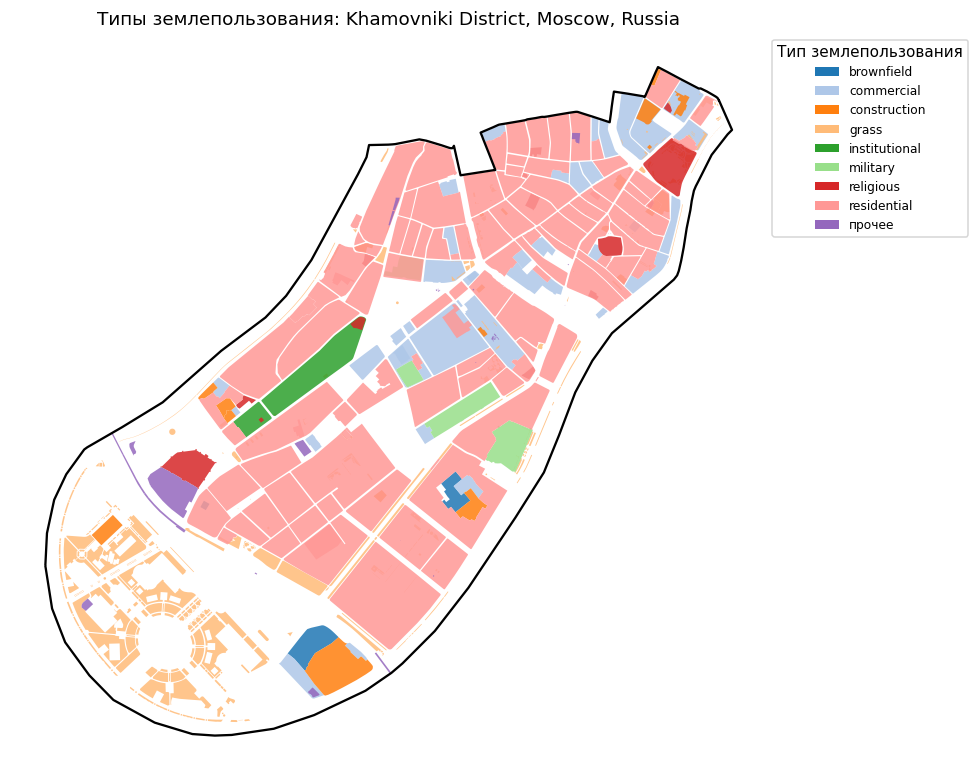

In [13]:
# Берём топ-категории, остальное — "прочее", чтобы легенда была читаемой
TOP_N = 8
top_types = by_type.head(TOP_N).index.tolist()
lu_plot = landuse_m.copy()
lu_plot["lu_cat"] = lu_plot["landuse"].where(lu_plot["landuse"].isin(top_types), "прочее")

cmap = plt.get_cmap("tab20")
categories = sorted(lu_plot["lu_cat"].unique())
colors = {c: cmap(i % 20) for i, c in enumerate(categories)}

fig, ax = plt.subplots(figsize=(9, 9))
boundary_m.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, zorder=3)
for c in categories:
    sub = lu_plot[lu_plot["lu_cat"] == c]
    sub.plot(ax=ax, color=colors[c], edgecolor="none", alpha=0.85, zorder=2)

handles = [Patch(facecolor=colors[c], label=c) for c in categories]
ax.legend(handles=handles, title="Тип землепользования",
          loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.set_title(f"Типы землепользования: {PLACE}", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


### 7.3 Структура землепользования

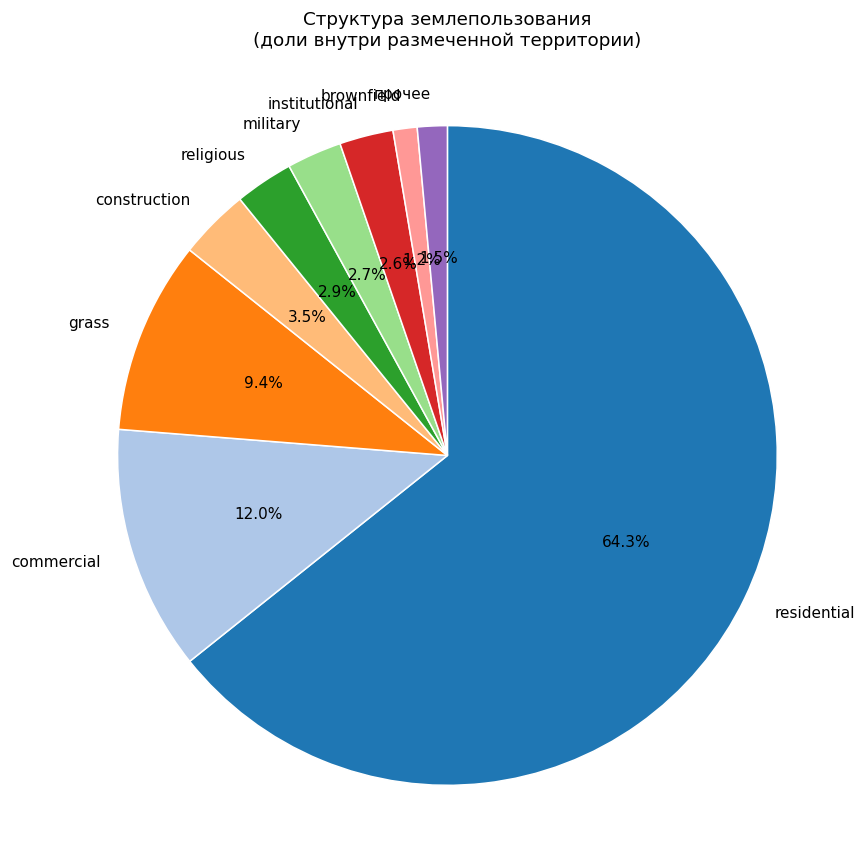

In [14]:
# Топ-категории + объединённое "прочее"
pie = by_type.head(TOP_N).copy()
other = by_type.iloc[TOP_N:].sum()
if other > 0:
    pie["прочее"] = other

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(pie.values, labels=pie.index, autopct="%1.1f%%",
       startangle=90, counterclock=False,
       colors=[cmap(i % 20) for i in range(len(pie))],
       wedgeprops={"edgecolor": "white", "linewidth": 1})
ax.set_title("Структура землепользования\n(доли внутри размеченной территории)",
             fontsize=12)
ax.axis("equal")
plt.tight_layout()
plt.show()


## 8. Сохранение данных

Складываю очищенные слои в GeoPackage, чтобы при желании открыть их в QGIS.

In [15]:
OUT = "khamovniki_landuse.gpkg"
buildings_m.to_file(OUT, layer="buildings", driver="GPKG")
landuse_m.to_file(OUT, layer="landuse", driver="GPKG")
boundary_m.to_file(OUT, layer="boundary", driver="GPKG")
print("Сохранено в", OUT)


Сохранено в khamovniki_landuse.gpkg


## 9. Выводы

In [16]:
dominant = by_type.index[0]
dominant_share = by_type.iloc[0] / total_landuse_area * 100
coverage = total_landuse_area / district_area * 100

print(f"Площадь района:              {district_area/1e6:.2f} км²")
print(f"Доля застроенной территории: {pct_union:.1f}%")
print(f"Размечено зонами landuse:    {coverage:.0f}% площади района")
print(f"Преобладающий тип:           {dominant} ({dominant_share:.1f}% размеченной площади)")

Площадь района:              10.07 км²
Доля застроенной территории: 20.3%
Размечено зонами landuse:    61% площади района
Преобладающий тип:           residential (64.3% размеченной площади)


### Выводы о районе

- Застройка занимает около **20%** территории Хамовников (район ~10 км², почти 2800
  зданий) — для центра это умеренная плотность: между домами много дворов, скверов и
  широких улиц.
- Зонами `landuse` в OSM размечено лишь ~**61%** района, поэтому доли на круговой
  диаграмме относятся к размеченной части, а не ко всей территории — это держу в голове
  при интерпретации.
- В размеченной части резко преобладает жилая функция (`residential`, ~**64%**), дальше
  с большим отрывом идут `commercial` и зелёные зоны (`grass`). То есть Хамовники —
  прежде всего жилой район с заметным деловым и зелёным каркасом.
- Главное ограничение — полнота OSM: часть зданий и зон не размечена или размечена
  грубо, поэтому все цифры читаю как оценку, а не как точный кадастр.